<img src="https://upload.wikimedia.org/wikipedia/commons/c/cc/Uber_logo_2018.png" alt="UBER" width="150" />

# Where should the drivers be?

Uber's product team wants the app to **recommend hot zones to drivers, in a major city, at any
given time of day.** The reason is a number from their own research: a rider accepts a wait of
**5 to 7 minutes** and cancels beyond it.

This notebook builds those zones for New York, from a file of 4.5 million pickups. It answers the three
things the brief asks for — a map, a description **per day of week**, and a comparison of **two
unsupervised algorithms** — and two of the three answers are not the expected ones:

> **The day of week is the weak axis.** The map of demand moves twice as much between two hours of
> the same day as between two days of the week. Two *adjacent* hours differ almost as much as an
> average pair of days.
>
> **DBSCAN cannot answer this question, and the reason is interesting.** It looks for zones
> separated by empty space; Manhattan has none. At every parameter setting it returns one cluster
> holding three quarters of the city, or throws away a third of the demand as noise.

Everything below is the evidence for those sentences.

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | Load the pickups and establish what one row is |
| 2 | What looks like cleaning here — and what each rule would cost |
| 3 | Where the demand is, and when |
| 4 | Hot zones with KMeans — how many zones, and where |
| 5 | Hot zones with DBSCAN — and what the comparison really says |
| 6 | What Uber should ship |

## 1. The pickups

In [1]:
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

import shapely
from shapely.geometry import shape

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
# One figure is the exception -- the map in section 3, whose whole point is its day-and-hour
# control. show_interactive() keeps it live and still writes a frame to images/ for the README.
# The maps need a network connection when they are rendered: the basemap tiles are fetched
# from CARTO / OpenStreetMap. The interactive figure is stored as a Plotly
# mimetype, which a running notebook renders on its own.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README and the oral presentation can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One seed for the whole notebook: every KMeans fit and every DBSCAN sample reads it, so every
# number below is reproducible from this line.
RANDOM_STATE = 42

# The palette: one blue for a single measure, blue/red when a chart carries a contrast.
BLUE, RED, GREY = '#2a78d6', '#e34948', '#8a8a85'

DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()


def show_interactive(fig, name, height=520):
    """Same, but the figure keeps its controls alive in a notebook that is actually running."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=90, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show(renderer='plotly_mimetype')

In [2]:
FILES = sorted(Path('data/uber-trip-data').glob('uber-raw-data-*14.csv'))
raw = pd.concat([pd.read_csv(f) for f in FILES], ignore_index=True)

print(f'{len(FILES)} monthly files -> {len(raw):,} pickups x {raw.shape[1]} columns'.replace(',', ' '))
raw.head()

6 monthly files -> 4 534 327 pickups x 4 columns


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [3]:
# What pandas made of the six CSVs. A CSV carries no types, so read_csv guesses column by column:
# the coordinates come back as numbers, the two others as text — the `str` dtype of pandas 3.
schema = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'distinct': raw.nunique().map('{:,}'.format).str.replace(',', ' '),
    'example': raw.iloc[0].astype(str),
}).rename_axis('column').reset_index()
print(schema.to_string(index=False))

   column   dtype distinct          example
Date/Time     str  260 093 4/1/2014 0:11:00
      Lat float64    7 092           40.769
      Lon float64   11 453         -73.9549
     Base     str        5           B02512


### What is one row, and what is in the archive

**One row is one pickup**: the minute it happened, where it happened, and the Uber base that
dispatched it. There is no drop-off, no rider, no fare, no duration — the file is a stream of
points in space and time.

The archive also contains **`uber-raw-data-janjune-15.csv.zip`**, six more months of pickups. It is
not used here, and the reason is not a preference: that file has no coordinates. It identifies a
pickup by `locationID`, a taxi-zone index — the answer to "where should the driver be" is already
pre-aggregated into somebody else's 265 zones, which is the very thing this project has to build.
The cell below shows both formats side by side.

In [4]:
with zipfile.ZipFile('data/uber-trip-data/uber-raw-data-janjune-15.csv.zip') as z:
    with z.open('uber-raw-data-janjune-15.csv') as f:
        print('2015 file :', ', '.join(pd.read_csv(f, nrows=1).columns))
print('2014 files:', ', '.join(raw.columns))

when = pd.to_datetime(raw['Date/Time'], format='%m/%d/%Y %H:%M:%S')
print(f'\nperiod   : {when.min():%d %b %Y} to {when.max():%d %b %Y}')
print(f'missing  : {raw.isna().sum().sum()}')
print(f'per month:')
print(when.dt.month.value_counts().sort_index()
      .rename(lambda m: f'  2014-{m:02d}').to_string())

2015 file : Dispatching_base_num, Pickup_date, Affiliated_base_num, locationID
2014 files: Date/Time, Lat, Lon, Base



period   : 01 Apr 2014 to 30 Sep 2014
missing  : 0
per month:
Date/Time
2014-04     564516
2014-05     652435
2014-06     663844
2014-07     796121
2014-08     829275
2014-09    1028136


Six months, **April to September 2014**, and the volume grows every single one of them: 564 516
pickups in April, **1 028 136 in September**, an 82% increase in half a year. Nothing is missing.

That growth is worth keeping in mind for the rest of the notebook: this is a market being built,
not a stable one being measured, so every share below is a share of a moving total.

## 2. What looks like cleaning here — and what it would cost

### 2.1 The 82 581 duplicated rows are two riders, not one pickup counted twice

In [5]:
groups = raw.groupby(['Date/Time', 'Lat', 'Lon', 'Base'], observed=True).size()
per_minute = raw.groupby('Date/Time').size()   # one count per dated minute, read three times below
dup = raw.duplicated()

print(f'rows drop_duplicates() would delete : {dup.sum():,} ({dup.mean():.2%})'.replace(',', ' '))
print(f'identical-row groups by size       :')
print(groups.value_counts().sort_index().rename(lambda n: f'  {n} identical rows').to_string())
print(f'\ndistinct minutes in the file       : {len(per_minute):,}'.replace(',', ' '))
print(f'pickups started in one minute      : median {per_minute.median():.0f}, '
      f'max {per_minute.max()}')

rows drop_duplicates() would delete : 82 581 (1.82%)
identical-row groups by size       :
1 identical rows    4369343
2 identical rows      82225
3 identical rows        178

distinct minutes in the file       : 260 093
pickups started in one minute      : median 16, max 97


A row is duplicated when two pickups share a minute, a position **and** a base. With a
median of 16 pickups a minute across the city and 260 093 minutes in the file, the 82 581
duplicated rows form **82 225 pairs, 178 triples, and nothing larger**.

### 2.2 The 122 454 pickups outside New York, on the other hand, go

In [6]:
# The brief scopes the project to New York City, so the rule is the city's own boundary rather
# than a rectangle: the five boroughs as published by the Department of City Planning, clipped to
# the shoreline. BOX survives only as what it honestly is -- the origin of the 500 m grid below.
BOX = dict(lat=(40.45, 41.00), lon=(-74.30, -73.65))

boro = np.full(len(raw), 'outside New York City', dtype=object)
for feature in json.loads(Path('data/nyc_boroughs.geojson').read_text())['features']:
    todo = boro == 'outside New York City'        # a pickup belongs to one borough at most
    hit = np.zeros(len(raw), dtype=bool)
    hit[todo] = shapely.contains_xy(shape(feature['geometry']),
                                    raw['Lon'].values[todo], raw['Lat'].values[todo])
    boro[hit] = feature['properties']['BoroName']

inside = boro != 'outside New York City'
per_boro = pd.Series(boro).value_counts()
print(f'{"borough":<24}{"pickups":>12}{"share":>8}')
for name in ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island', 'outside New York City']:
    n = per_boro.get(name, 0)
    print(f'{name:<24}{n:>12,}'.replace(',', ' ') + f'{n / len(raw):>8.2%}')

far = raw[~inside]
reach = (f'lat {far["Lat"].min():.2f} to {far["Lat"].max():.2f}, '
         f'lon {far["Lon"].min():.2f} to {far["Lon"].max():.2f}')
print(f'\nthe {(~inside).sum():,}'.replace(',', ' ') + f' dropped reach {reach}')

df = raw[inside].copy()
df['boro'] = boro[inside]
df['hour'] = when[inside].dt.hour.values
df['dow'] = when[inside].dt.dayofweek.values
print(f'kept for the rest of the notebook: {len(df):,} pickups'.replace(',', ' '))

borough                      pickups   share
Manhattan                  3 443 435  75.94%
Brooklyn                     593 610  13.09%
Queens                       342 208   7.55%
Bronx                         31 586   0.70%
Staten Island                  1 034   0.02%
outside New York City        122 454   2.70%

the 122 454 dropped reach lat 39.66 to 42.12, lon -74.93 to -72.07


kept for the rest of the notebook: 4 411 873 pickups


The rule is the city's own boundary: a pickup is kept when it falls inside one of the five
boroughs, as the Department of City Planning draws them. `data/nyc_boroughs.geojson` is that file.

It costs **122 454 pickups, 2.70% of the file**, reaching latitude 39.66 to 42.12 and longitude
-74.93 to -72.07. **4 411 873 pickups** are kept, and every section below runs on them.

The table is also the answer to *where the demand is*, before any clustering: **Manhattan alone
carries 75.94%**, Brooklyn 13.09% and Queens 7.55%. The Bronx contributes 0.70%, and Staten Island
0.02% — 1 034 pickups in six months.

## 3. Where the demand is, and when

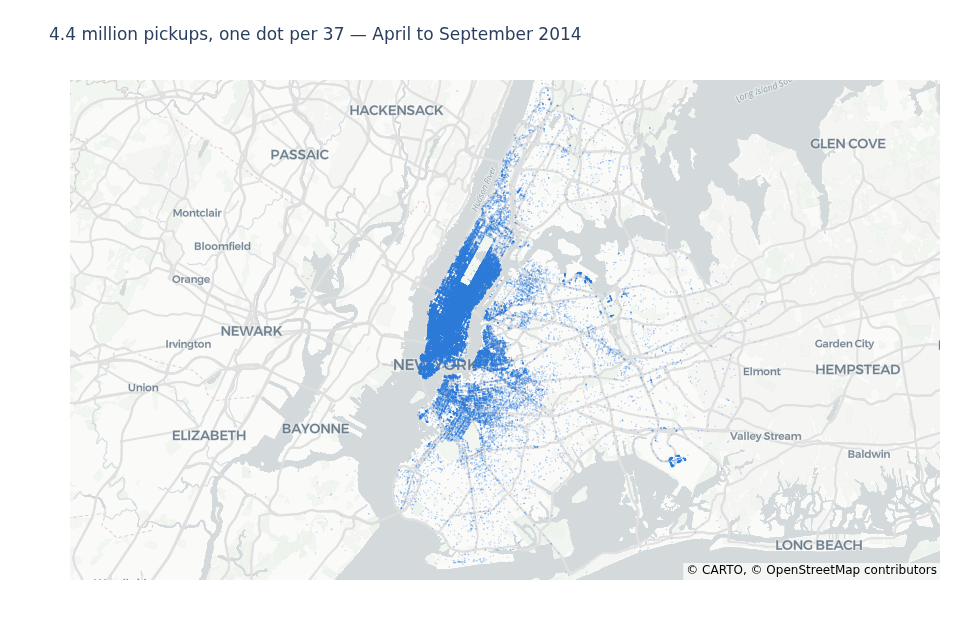

In [7]:
sample = df.sample(120_000, random_state=RANDOM_STATE)
fig = go.Figure(go.Scattermap(
    lat=sample['Lat'], lon=sample['Lon'], mode='markers',
    marker=dict(size=2.5, color=BLUE, opacity=0.25), hoverinfo='skip',
))
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=40.735, lon=-73.94), zoom=9.6),
    title=f'{len(df) / 1e6:.1f} million pickups, one dot per {round(len(df) / len(sample))} '
          f'— April to September 2014',
    showlegend=False,
)
show(fig, '1_pickups_density', height=640)

That map is the table of section 2.2, drawn. **Manhattan (75.94%)** saturates into a solid block.
**Brooklyn (13.09%)** is dense along the water facing it and grains out to the south, **Queens
(7.55%)** spreads thinly along its avenues with two bright patches, the **Bronx (0.70%)** is a
scatter at the top, and **Staten Island (0.02%)** shows nothing at this scale — 1 034 pickups in
six months.

New Jersey is blank, and that is the rule of 2.2 made visible.

### 3.1 Every day has its own clock

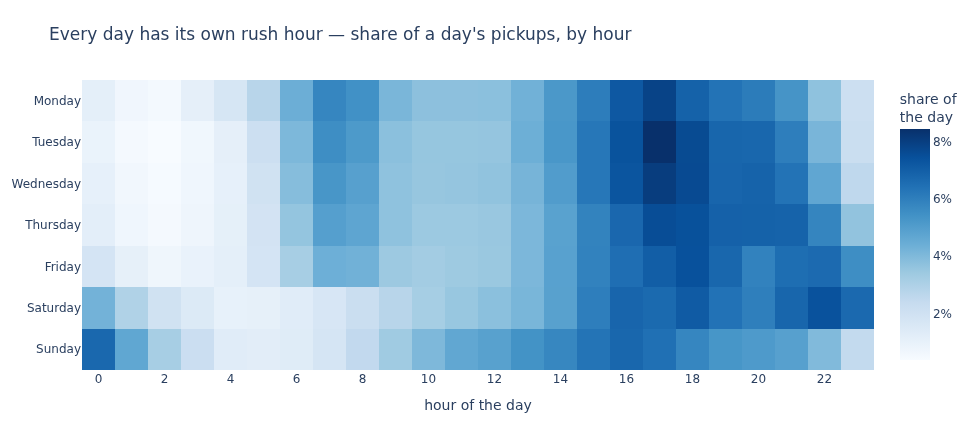

    peak %_peak %_week
Mon  17h   7.8%  11.9%
Tue  17h   8.4%  14.7%
Wed  17h   8.0%  15.4%
Thu  17h   7.5%  16.7%
Fri  18h   7.4%  16.4%
Sat  22h   7.4%  14.2%
Sun  16h   6.7%  10.7%


In [8]:
by_hour_day = df.groupby(['dow', 'hour']).size().unstack()
share_within_day = by_hour_day.div(by_hour_day.sum(axis=1), axis=0)

fig = go.Figure(go.Heatmap(
    z=share_within_day.values, x=list(range(24)), y=DAYS,
    colorscale='Blues', colorbar=dict(title='share of<br>the day', tickformat='.0%'),
))
fig.update_layout(
    title="Every day has its own rush hour — share of a day's pickups, by hour",
    xaxis=dict(title='hour of the day', dtick=2), yaxis=dict(autorange='reversed'),
)
show(fig, '2_the_clock', height=430)

# Each day's own clock: the hour it peaks at, how much of that day the peak holds, and -- on a
# different denominator -- how much of the whole week the day is worth.
clock = pd.DataFrame({
    'peak': share_within_day.idxmax(axis=1).map('{}h'.format),
    '%_peak': share_within_day.max(axis=1),
    '%_week': df['dow'].value_counts(normalize=True).sort_index(),
})
clock.index = [d[:3] for d in DAYS]
print(clock.to_string(formatters={c: '{:.1%}'.format for c in ['%_peak', '%_week']}))

**Monday to Friday the demand is a commute.** The heatmap exposes it: a band
lights up when offices fill, the middle of the day goes pale, and a wider, darker band appears when
they empty.

**Saturday and Sunday run on a different clock.** The morning band disappears entirely and the
colour moves to the two edges of the row — the small hours on the left, the late evening on the
right. The `peak` column puts a time on the shift: 17h from Monday to Thursday, 18h on Friday, then
22h on a Saturday and 16h on a Sunday.

The sharpest peak of the week is Tuesday's, which holds **8.4%** of its day. The busiest day is
Thursday, at **16.7%** of the week. They are not the same day.

In [9]:
# The 500 m grid the notebook uses from here on: a fixed lattice over the box, not a square drawn
# around each pickup.
CELL = 0.0045, 0.0059                     # ~500 m of latitude, ~500 m of longitude at 40.75 N
cell_id = (((df['Lat'] - BOX['lat'][0]) / CELL[0]).astype(int) * 100_000
           + ((df['Lon'] - BOX['lon'][0]) / CELL[1]).astype(int))

# One frame per (day, hour). Cells under 5 pickups in their hour are dropped, so the figure
# stays under a few megabytes.
MIN_PICKUPS, RADIUS = 5, 14
cells = df.assign(cell=cell_id).groupby(['dow', 'hour', 'cell']).size().rename('n')
grid = cells.reset_index().query('n >= @MIN_PICKUPS')
grid['lat'] = BOX['lat'][0] + (grid['cell'] // 100_000 + 0.5) * CELL[0]
grid['lon'] = BOX['lon'][0] + (grid['cell'] % 100_000 + 0.5) * CELL[1]
hourly = df.groupby(['dow', 'hour']).size()

# Manhattan holds two orders of magnitude more demand than the airports, so on a linear scale the
# rest of the city is invisible. The colour is log10(pickups); the colourbar is labelled in
# pickups, so nothing has to be read off a log axis.
TICKS = [5, 10, 25, 50, 100, 250, 500, 1000, 2000]
BLUE_RAMP = [[0.00, 'rgba(232,240,251,0.00)'], [0.12, 'rgba(168,198,236,0.45)'],
             [0.35, 'rgba(95,154,224,0.70)'], [0.60, 'rgba(42,120,214,0.85)'],
             [0.82, 'rgba(28,82,150,0.92)'], [1.00, 'rgba(18,50,85,0.97)']]


def density(d, h):
    """One frame: the 500 m cells that saw at least MIN_PICKUPS pickups, that day at that hour."""
    s = grid[(grid['dow'] == d) & (grid['hour'] == h)]
    return go.Densitymap(
        lat=s['lat'], lon=s['lon'], z=np.log10(s['n']), radius=RADIUS,
        colorscale=BLUE_RAMP, zmin=np.log10(TICKS[0]), zmax=np.log10(TICKS[-1]),
        hovertemplate='%{z:.0f}<extra></extra>',
        colorbar=dict(title='pickups in a<br>500 m cell', thickness=12,
                      tickvals=np.log10(TICKS), ticktext=[str(t) for t in TICKS]))


def caption(d, h):
    return f'{DAYS[d]} {h:02d}h — {hourly[(d, h)]:,} pickups'.replace(',', ' ')


frames = [go.Frame(name=f'{d}-{h}', data=[density(d, h)], layout=go.Layout(title=caption(d, h)))
          for d in range(7) for h in range(24)]
# 168 labels would overlap, so only the start of each day is written; the title names the frame.
steps = [dict(method='animate', label=DAYS[d][:3] if h == 0 else '',
              args=[[f'{d}-{h}'], dict(mode='immediate', frame=dict(duration=0, redraw=True),
                                       transition=dict(duration=0))])
         for d in range(7) for h in range(24)]

START = 3 * 24 + 17                        # Thursday 17h, the busiest of the 168
fig = go.Figure(data=[density(3, 17)], frames=frames)
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=40.730, lon=-73.930), zoom=9.5),
    title=caption(3, 17), showlegend=False,
    sliders=[dict(active=START, x=0.06, len=0.94, y=0, pad=dict(t=10, b=10),
                  currentvalue=dict(visible=False), steps=steps)],
    updatemenus=[dict(type='buttons', showactive=False, x=0.0, y=0, xanchor='right', yanchor='top',
                      buttons=[dict(label='▶', method='animate',
                                    args=[None, dict(frame=dict(duration=400, redraw=True),
                                                     fromcurrent=True)])])])
show_interactive(fig, '2_demand_by_hour', height=660)

# The range the colour scale has to cover, borough by borough: the busiest square of an hour
# against the typical one. A cell takes the borough of most of its pickups.
cell_boro = df.assign(cell=cell_id).groupby('cell')['boro'].agg(lambda s: s.value_counts().idxmax())
spread = (grid.assign(borough=grid['cell'].map(cell_boro))
          .groupby('borough')['n'].agg(busiest='max', median='median').astype(int))
spread['factor'] = (spread['busiest'] / spread['median']).round().astype(int)
print(spread.reindex(['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']).to_string())

               busiest  median  factor
borough                               
Manhattan         2018      48      42
Brooklyn           301      13      23
Queens             843       9      94
Bronx              171       7      24
Staten Island        9       6       2


The slider walks the 168 pairs of (day, hour) and the title names the frame and gives its own volume.

The colour is **log10 of the pickups in a 500 m square**, and the table above is why. Calibrated on
the busiest square of Manhattan — **2 018 pickups in a single hour** — a linear ramp would hold the
whole range of Staten Island, **6 to 9**, inside its first percent. The colourbar is labelled in
pickups, so nothing has to be read off a log axis.

The spread is not the same everywhere either: the busiest square is **42 times** the typical one in
Manhattan, **94 times** in Queens, and **twice** in Staten Island.

This map puts the two blocks above together. The first gave the shape of the demand, the clock gave
its hours; the slider shows both at once — the same shape being redrawn, hour by hour.

## 4. Hot zones with KMeans

### 4.1 First, the coordinates have to be in metres

KMeans minimises a Euclidean distance, so it treats one unit of the first column like one unit of
the second. Feeding it raw `(Lon, Lat)` means adding degrees of longitude to degrees of latitude,
and at this latitude those are not the same ground distance: a degree going east covers 84 km
against 111 going north. The same kilometre would weigh a third more when it runs east-west — and
Manhattan is a north-south island.

Everything below therefore clusters on `XY`, in kilometres. Only the final zone centres are turned
back into latitude and longitude, which is what the brief asks to pin the hot zones with.

In [10]:
# KMeans minimises a Euclidean distance, so it treats one unit of x like one unit of y. Degrees
# do not satisfy that, and the two numbers printed below are the whole reason this cell exists.
EARTH_KM, LAT0 = 6371.0, np.radians(40.75)


def to_km(lat, lon):
    """Local flat projection around New York: degrees -> kilometres, x east, y north."""
    return np.column_stack([EARTH_KM * np.cos(LAT0) * np.radians(lon), EARTH_KM * np.radians(lat)])


XY = to_km(df['Lat'].values, df['Lon'].values)

east, north = EARTH_KM * np.cos(LAT0) * np.radians(1), EARTH_KM * np.radians(1)
print(f'1 degree of longitude here: {east:.1f} km   1 degree of latitude: {north:.1f} km')
print(f'on raw degrees the same kilometre would weigh {north / east:.2f} times more going east')

1 degree of longitude here: 84.2 km   1 degree of latitude: 111.2 km
on raw degrees the same kilometre would weigh 1.32 times more going east


### 4.2 How many zones?

KMeans has to be told how many zones to build, and a continuous density gives no answer. Two
criteria are put side by side below, one from clustering and one from the brief.

The first is the silhouette. For each ride it compares the average distance to the other rides of
its own zone against the average distance to those of the nearest other zone, and reports how much
larger the second is: one means zones separated by open space, zero means a ride sits as close to
the neighbouring zone as to its own. It compares every point to every other one of its cluster, so
it cannot run on 4.4 million rides — it runs on 50 000 drawn once, on the seed fixed in section 1.

The second is the wait. **A rider accepts 5 to 7 minutes and cancels beyond it**, says the brief —
but that is a duration, and the file holds none to convert it with. The speed comes from outside,
**15.7 km/h**, TomTom's traffic index for New York. Five, six and seven minutes buy 1.31, 1.57 and
1.83 km, and every cut is priced at all three rather than at one.

Ten values of k are fitted on the whole city. Each ride is then measured against the centre of the
zone it falls in, and the rides left further away than the wait allows are counted as cancelled.

In [11]:
# The brief gives a wait, not a distance, and the file has nothing to convert it with -- no
# duration, no destination. The speed is therefore an external input, cited rather than assumed:
# TomTom's traffic index puts New York's average at 15.7 km/h.
# https://www.tomtom.com/traffic-index/city/new-york-ny/
KMH, WAITS = 15.7, (5, 6, 7)
K_GRID = [4, 6, 8, 10, 12, 15, 20, 25, 30, 40]

# The silhouette compares every point to every other one of its cluster, so it cannot run on
# 4.4 million; 50 000 drawn once is enough to see that it stays flat.
sil_sample = np.random.default_rng(RANDOM_STATE).choice(len(XY), 50_000, replace=False)

rows = []
for k in K_GRID:
    km = KMeans(k, n_init=5, random_state=RANDOM_STATE).fit(XY)
    d = np.linalg.norm(XY - km.cluster_centers_[km.labels_], axis=1)   # km from a ride to its zone
    rows.append({'k': k, 'median_km': np.median(d),
                 **{f'{m}_min': (d >= KMH * m / 60).mean() for m in WAITS},
                 'silhouette': silhouette_score(XY[sil_sample], km.labels_[sil_sample])})
sweep = pd.DataFrame(rows)

print(f'rides cancelled -- the rider is further from the zone centre than the wait buys at {KMH} km/h')
print('  ' + '    '.join(f'{m} min = {KMH * m / 60:.2f} km' for m in WAITS) + '\n')
print(sweep.to_string(index=False, formatters={
    'median_km': '{:.3f}'.format, 'silhouette': '{:.3f}'.format,
    **{f'{m}_min': '{:.1%}'.format for m in WAITS}}))

rides cancelled -- the rider is further from the zone centre than the wait buys at 15.7 km/h
  5 min = 1.31 km    6 min = 1.57 km    7 min = 1.83 km

 k median_km 5_min 6_min 7_min silhouette
 4     1.944 71.9% 63.2% 53.7%      0.427
 6     1.477 56.9% 46.1% 36.1%      0.473
 8     1.263 47.7% 33.8% 21.7%      0.450
10     1.059 34.4% 22.3% 15.0%      0.419
12     1.026 31.2% 20.1% 13.2%      0.417
15     0.872 20.3% 13.1%  9.2%      0.405
20     0.770 15.3%  8.9%  5.8%      0.401
25     0.674  9.7%  6.2%  4.3%      0.406
30     0.612  8.0%  4.8%  3.2%      0.403
40     0.519  5.4%  3.6%  2.4%      0.381


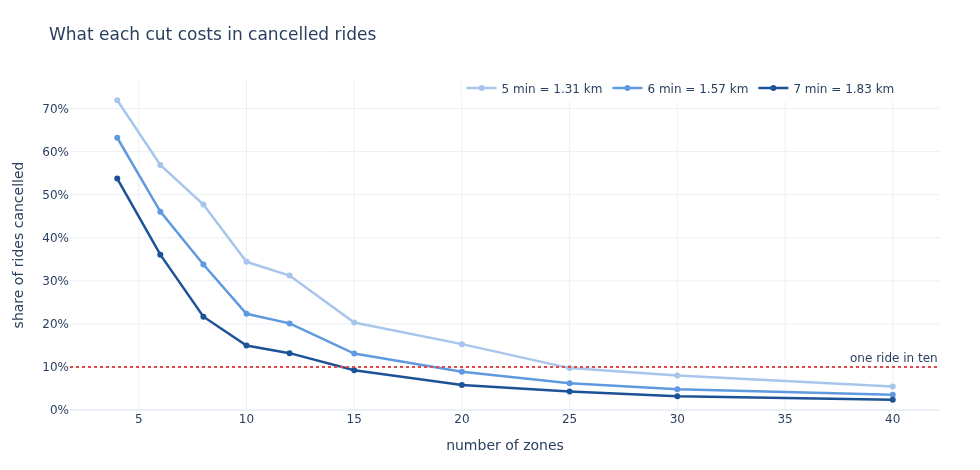

In [12]:
# One axis, one unit: three readings of the same brief, not two quantities forced onto two scales.
# The colour is an ordinal ramp -- more minutes of patience, darker line.
fig = go.Figure()
for m, colour in zip(WAITS, ('#a8c6ec', '#5f9ae0', '#1c5296')):
    fig.add_trace(go.Scatter(x=sweep['k'], y=sweep[f'{m}_min'], mode='lines+markers',
                             name=f'{m} min = {KMH * m / 60:.2f} km', line=dict(color=colour, width=2.5)))
fig.add_hline(y=0.10, line_dash='dot', line_color=RED,
              annotation_text='one ride in ten', annotation_position='top right')
fig.update_layout(
    title='What each cut costs in cancelled rides',
    xaxis=dict(title='number of zones', dtick=5),
    yaxis=dict(title='share of rides cancelled', tickformat='.0%', rangemode='tozero'),
    legend=dict(orientation='h', y=1.02, x=0.45),
)
show(fig, '3_choosing_k', height=470)

The silhouette stays between **0.381 and 0.473** across the whole grid, and its best value falls on
`k = 6`. That cut leaves between **36.1% and 56.9%** of rides beyond the wait, depending on which
reading is taken. The metric compares each ride's distance to its own zone against its distance to
the nearest other zone: it scores the shape of the partition, and carries no term for the wait, the
rider or the cancelled ride. Its optimum is a geometric one, not the product's — which is why the
column is printed here and not acted on.

**k = 25** is the smallest cut that keeps cancellations under one ride in ten even at the strictest
reading, five minutes: **9.7%**, against 15.3% at k = 20. At six minutes it loses **6.2%**,
with the median rider **674 m** from the centre of their zone. It is also where the curves flatten —
past 25, an added zone buys a fraction of what it bought before.

### 4.3 The zones

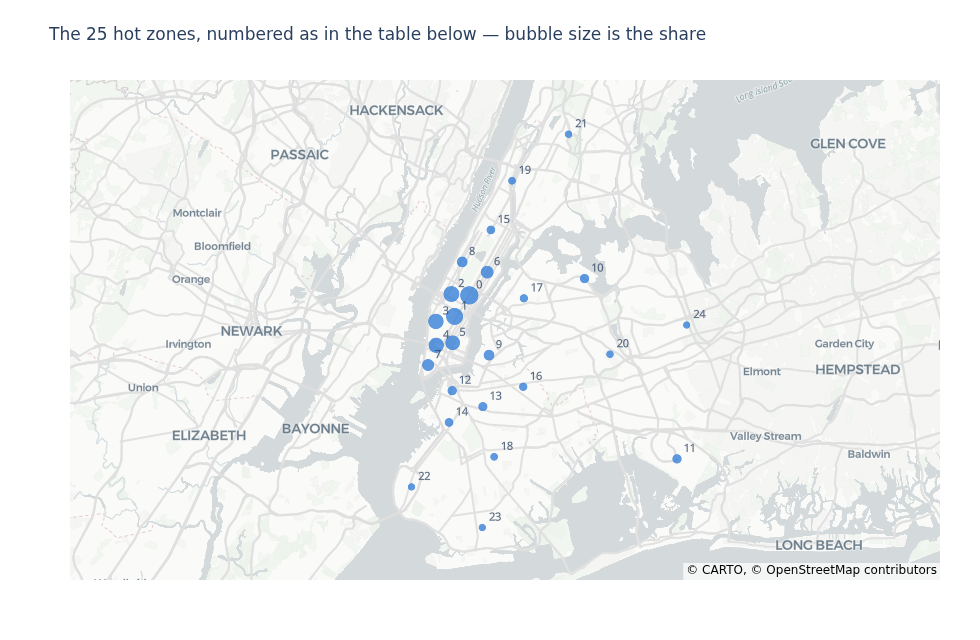

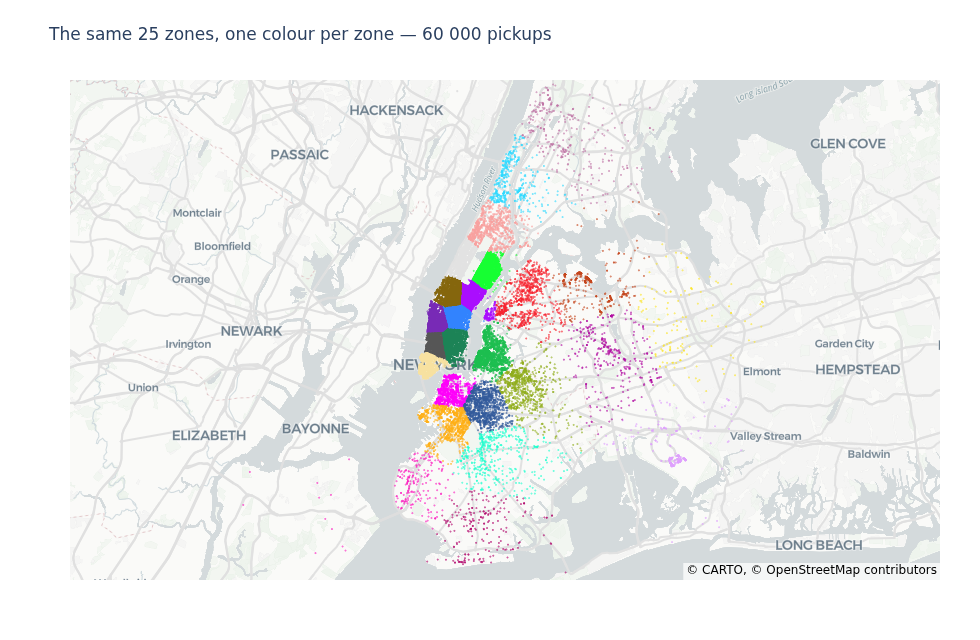

        lat      lon  pickups   share  peak_hour peak_day
0   40.7588 -73.9723   552024  0.1251         17      Wed
1   40.7443 -73.9857   485455  0.1100         17      Thu
2   40.7597 -73.9886   430949  0.0977         17      Wed
3   40.7409 -74.0026   408272  0.0925         21      Sat
4   40.7245 -74.0022   401583  0.0910         17      Thu
5   40.7263 -73.9874   374203  0.0848         22      Sat
6   40.7747 -73.9562   279372  0.0633          7      Tue
7   40.7109 -74.0097   236898  0.0537         17      Fri
8   40.7817 -73.9788   182682  0.0414          7      Mon
9   40.7177 -73.9544   180309  0.0409         22      Sun
10  40.7703 -73.8680   113362  0.0257         20      Sun
11  40.6464 -73.7842   111291  0.0252         14      Sun
12  40.6933 -73.9879   109057  0.0247         17      Sat
13  40.6824 -73.9600   101208  0.0229         21      Sat
14  40.6715 -73.9907    82309  0.0187         21      Sat
15  40.8037 -73.9527    81933  0.0186         17      Sun
16  40.6960 -7

In [13]:
K = 25
kmeans = KMeans(K, n_init=10, random_state=RANDOM_STATE).fit(XY)
# KMeans numbers its clusters in whatever order it finds them. Renumbering by weight gives the
# index a meaning -- zone 0 is the busiest -- and df['zone'] is remapped with it, so the
# table below reads in order.
order = np.argsort(-np.bincount(kmeans.labels_, minlength=K))
rank = np.empty(K, dtype=int)
rank[order] = np.arange(K)
df['zone'] = rank[kmeans.labels_]

centres = kmeans.cluster_centers_[order]
zones = pd.DataFrame({'lat': np.degrees(centres[:, 1] / EARTH_KM),
                      'lon': np.degrees(centres[:, 0] / (EARTH_KM * np.cos(LAT0))),
                      'pickups': df['zone'].value_counts().sort_index().values})
zones['share'] = zones['pickups'] / len(df)
zones['peak_hour'] = df.groupby('zone')['hour'].agg(lambda s: s.value_counts().idxmax())
# peak_day is normalised: each day's share inside the zone is divided by that day's share of
# the whole city, so it names the day the zone over-indexes on -- not its busiest day.
zones['peak_day'] = df.groupby('zone')['dow'].agg(lambda s: (s.value_counts() /
                                                             df['dow'].value_counts()).idxmax())
zones['peak_day'] = zones['peak_day'].map(lambda d: DAYS[d][:3])

fig = go.Figure(go.Scattermap(
    lat=zones['lat'], lon=zones['lon'], mode='markers+text',
    marker=dict(size=8 + 90 * zones['share'], color=BLUE, opacity=0.75),
    # The label is the zone number, not its share: the bubble size already carries the share,
    # and the number is what links a bubble to its row in the table printed below.
    text=zones.index.astype(str), textposition='top right',
    textfont=dict(size=11), hoverinfo='skip',
))
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=40.735, lon=-73.94), zoom=9.6),
    title=f'The {K} hot zones, numbered as in the table below — bubble size is the share',
    showlegend=False,
)
show(fig, '4_zones_map', height=640)

# The same fit drawn the way the brief's example draws it: the pickups coloured by the zone they
# fall in, which shows the partition rather than its anchors. With twenty-five zones the colour
# only separates neighbours -- two distant zones may share a shade.
shown = df.sample(60_000, random_state=RANDOM_STATE)
palette = px.colors.qualitative.Alphabet
fig = go.Figure()
for z in range(K):
    part = shown[shown['zone'] == z]
    fig.add_trace(go.Scattermap(lat=part['Lat'], lon=part['Lon'], mode='markers',
                                marker=dict(size=3, color=palette[z % len(palette)], opacity=0.6),
                                hoverinfo='skip'))
drawn = f'{len(shown):,}'.replace(',', ' ')
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=40.735, lon=-73.94), zoom=9.6),
    title=f'The same {K} zones, one colour per zone — {drawn} pickups',
    showlegend=False,
)
show(fig, '4_zones_coloured', height=640)

print(zones.round(4).to_string())   # already in rank order: the index is the rank

share = zones['share']
print(f'\n{K} zones, from {share.max():.2%} of the demand down to {share.min():.2%} '
      f'-- a factor of {share.max() / share.min():.0f}')
print(f'the five biggest carry {share.nlargest(5).sum():.1%}, the thirteen smallest '
      f'{share.nsmallest(13).sum():.1%}')
print(f'peak hours run from {zones["peak_hour"].min()}h to {zones["peak_hour"].max()}h, '
      f'over {zones["peak_hour"].nunique()} distinct hours')

The demand is not spread evenly over the twenty-five zones. The biggest carries **12.51%** of it
and the smallest **0.23%**, a factor of fifty-three; five zones hold **51.6%**, while the thirteen
smallest together hold **14.9%** — less than the top two.

The `peak_hour` column runs from **7h to 22h** over seven distinct hours: two zones have their
busiest hour at 7h, three at 22h. `peak_day` does not pair with it: it names the day a zone
over-indexes on, not its busiest day, and the two columns are computed apart.

## 5. Hot zones with DBSCAN

DBSCAN asks a different question: not *"where do I put 25 pins"* but *"which points sit in a dense
neighbourhood, and which are noise"*. It needs no `k`, it finds clusters of any shape, and it can
refuse to classify a point at all — everything KMeans cannot do.

Two practical points before the results. Distances go through the **haversine** metric on radians,
so `eps` is a real distance on the globe and not a mix of degrees that measure different things.
And DBSCAN compares every point to its neighbours, which does not scale to 4.4 million: it runs on
samples, the first cell on four sizes and the rest on 100 000 — with `min_samples` scaled to the
sample, so that the density threshold it enforces stays the same one.

In [14]:
EARTH_M = 6_371_000.0
rng = np.random.default_rng(RANDOM_STATE)


def dbscan_on_sample(n, eps_m, min_samples):
    """Fit DBSCAN on a random sample of n pickups. Returns the labels and the sampled index."""
    idx = rng.choice(len(df), n, replace=False)
    radians = np.radians(df[['Lat', 'Lon']].values[idx])
    labels = DBSCAN(eps=eps_m / EARTH_M, min_samples=min_samples, metric='haversine',
                    algorithm='ball_tree', n_jobs=-1).fit(radians).labels_
    return labels, idx


print('does the sample decide the answer? same density threshold, four sample sizes')
print(f'{"sample":>8} {"min_samples":>12} {"clusters":>9} {"noise":>7} {"biggest cluster":>16}')
for n, ms in [(50_000, 25), (100_000, 50), (200_000, 100), (400_000, 200)]:
    labels, _ = dbscan_on_sample(n, 200, ms)
    sizes = np.bincount(labels[labels >= 0])
    print(f'{n:>8,} {ms:>12} {labels.max() + 1:>9} {(labels == -1).mean():>7.2%} '
          f'{sizes.max() / n:>16.2%}'.replace(',', ' '))

does the sample decide the answer? same density threshold, four sample sizes
  sample  min_samples  clusters   noise  biggest cluster


  50 000           25        37   9.17%           75.67%


 100 000           50        26   9.59%           76.14%


 200 000          100        27   9.51%           76.08%


 400 000          200        28   9.83%           76.12%


From 50 000 to 400 000 pickups the cluster count moves — 37 down to 26 — but the two numbers that
matter do not: noise stays under 10%, and **one cluster keeps three quarters of the city**, from
75.67% to 76.14% across an eightfold change of sample. That blob is not a sampling artefact, and
the next cell shows it is not a parameter artefact either.

does the parameter decide the answer? twelve settings on the same sample
   eps  min_samples  clusters   noise  biggest cluster
  100m           20       111  11.99%           75.23%
  100m           50        44  20.58%           69.13%
  100m          100        43  36.76%           50.60%
  200m           20        38   5.38%           76.67%
  200m           50        26   9.81%           75.82%
  200m          100        20  15.90%           75.15%
  300m           20        27   3.31%           77.36%
  300m           50        19   6.10%           76.71%
  300m          100        11   9.58%           75.96%
  500m           20        15   1.83%           94.84%
  500m           50        10   3.19%           77.76%
  500m          100         9   4.92%           77.36%


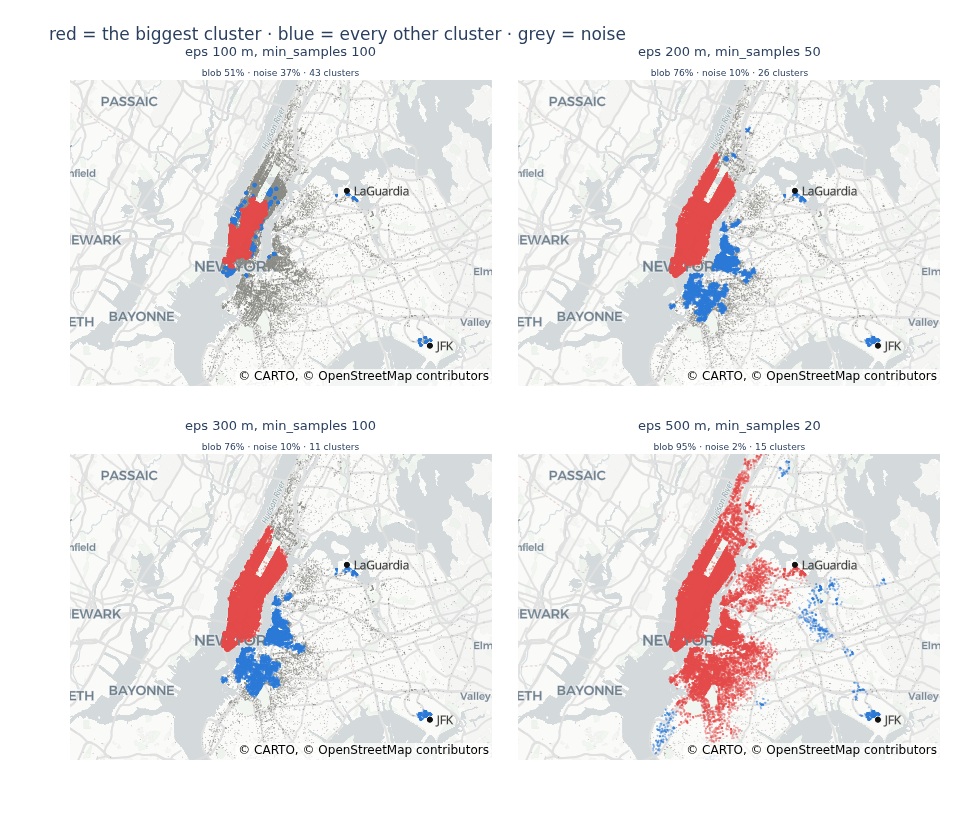

In [15]:
# The twelve settings, all fitted on ONE sample so the table and the panels are comparable --
# the helper above redraws a sample at every call, right for the size sweep, wrong for this one.
idx = rng.choice(len(df), 100_000, replace=False)
radians = np.radians(df[['Lat', 'Lon']].values[idx])
pts = df.iloc[idx]


def labels_for(eps_m, min_samples):
    """DBSCAN on that one sample; eps is given in metres and converted to radians."""
    return DBSCAN(eps=eps_m / EARTH_M, min_samples=min_samples, metric='haversine',
                  algorithm='ball_tree', n_jobs=-1).fit(radians).labels_


GRID = {(e, m): labels_for(e, m) for e in (100, 200, 300, 500) for m in (20, 50, 100)}
blob = {s: np.bincount(l[l >= 0]).max() / len(l) for s, l in GRID.items()}
noise = {s: (l == -1).mean() for s, l in GRID.items()}
print('does the parameter decide the answer? twelve settings on the same sample')
print(f'{"eps":>6} {"min_samples":>12} {"clusters":>9} {"noise":>7} {"biggest cluster":>16}')
for s, lab in GRID.items():
    print(f'{s[0]:>5}m {s[1]:>12} {lab.max() + 1:>9} {noise[s]:>7.2%} {blob[s]:>16.2%}')

# Four of the twelve: the two ways it fails, and two in between that agree.
SHOWN = [(100, 100), (200, 50), (300, 100), (500, 20)]
titles = [f'eps {e} m, min_samples {m}<br><sub>blob {blob[(e, m)]:.0%} · '
          f'noise {noise[(e, m)]:.0%} · {GRID[(e, m)].max() + 1} clusters</sub>' for e, m in SHOWN]
fig = make_subplots(rows=2, cols=2, specs=[[{'type': 'map'}] * 2] * 2,
                    subplot_titles=titles, horizontal_spacing=0.03, vertical_spacing=0.10)
for i, s in enumerate(SHOWN):
    lab = GRID[s]
    biggest = lab == np.bincount(lab[lab >= 0]).argmax()
    for mask, colour, size in ((lab == -1, GREY, 2), ((lab >= 0) & ~biggest, BLUE, 3),
                               (biggest, RED, 3)):
        fig.add_trace(go.Scattermap(lat=pts['Lat'][mask], lon=pts['Lon'][mask], mode='markers',
                                    marker=dict(size=size, color=colour, opacity=0.45),
                                    hoverinfo='skip', showlegend=False),
                      row=i // 2 + 1, col=i % 2 + 1)
# The two airports at their published coordinates, so the blue clusters can be read as places
# rather than as shapes: the point of the paragraph below is that DBSCAN lands on them unaided.
AIRPORTS = {'JFK': (40.6413, -73.7781), 'LaGuardia': (40.7769, -73.8740)}
for row in (1, 2):
    for col in (1, 2):
        fig.add_trace(go.Scattermap(
            lat=[p[0] for p in AIRPORTS.values()], lon=[p[1] for p in AIRPORTS.values()],
            mode='markers+text', text=list(AIRPORTS), textposition='middle right',
            marker=dict(size=7, color='#111111'), textfont=dict(size=12, color='#111111'),
            hoverinfo='skip', showlegend=False), row=row, col=col)

fig.update_maps(style='carto-positron', center=dict(lat=40.74, lon=-73.95), zoom=9.25)
fig.update_annotations(font_size=13)
fig.update_layout(title='red = the biggest cluster · blue = every other cluster · grey = noise',
                  margin=dict(t=90, b=20, l=20, r=20))
show(fig, '5_dbscan', height=820)



**Twelve settings, and the biggest cluster never drops below 51% of the sample.** Loosen `eps` and
the city fuses into a single **95% blob**; tighten it until the blob finally breaks apart, and
DBSCAN is throwing away **37% of the demand as noise** — noise that includes, by construction, the
quieter half of the city the drivers would still like to know about.

This is not DBSCAN failing. It is DBSCAN answering correctly that there is no empty space to
separate: density-based clustering isolates regions that are already apart, and this demand is one
continuous mass.

Read the blue clusters on the panels and the comparison stops being a verdict and becomes a
division of labour. What DBSCAN isolates is **exactly what water and runways already separate**:
the far bank of the East River, and the two airports — **JFK** and **LaGuardia**, marked on
the panels — found without being told they were there, which no KMeans run can claim.

| | KMeans | DBSCAN |
|---|---|---|
| answers | where do I send N drivers | which places are dense |
| number of zones | chosen — by the wait | emerges — 9 to 111, unusable as a list |
| the dense core | split into usable zones | one cluster, three quarters of the city |
| airports | found, as 2 of the 25 zones | found, as separate clusters |
| the quiet half of the city | assigned to its nearest zone | 2% to 37% discarded as noise |

**KMeans is the right tool here** — not because it scores better on a clustering metric, but
because the question is a placement problem with a budget of drivers, and that is what it solves.
DBSCAN's contribution is the map above: it proves the demand is one continuous mass, which is the
thing that makes any "natural zone" claim false.

## 6. What Uber should ship

**1. Twenty zones, refreshed hourly, is the product.** 20 zone centres put 85% of pickups within
1.5 km — the 5-to-7-minute wait the brief starts from. The map is in section 4.3.

**2. Index the recommendation by the hour first, and by weekday-versus-weekend second.** The map of
demand moves twice as much between two hours of the same day as between two days of the week, and
two adjacent hours move it almost as much as an average pair of days. A feature that recommends
"Thursday's zones" is indexing on the weaker variable; the day only matters through the shape it
gives the clock — commute on weekdays, nightlife at the weekend.

**3. Freeze the zone map and version it.** Re-fitting with another seed reassigns up to 17% of
pickups and moves a centre by 5.3 km, for less than 2% of inertia. The zones are one of many
near-equal answers, so the one that ships has to be pinned, not recomputed nightly.

**4. Treat the airports separately from the city.** JFK, LaGuardia and Newark are the only three
zones that a density algorithm finds unaided, they carry 6.2% of pickups between them, and their
clock is a flight schedule rather than a working day. They deserve their own supply rule.

**5. What the file cannot answer, and what to log for the next version.** There is no drop-off
here, so nothing in this notebook knows where a driver *ends up* after a ride — a zone that is easy
to leave is worth more than one that strands the driver. There is no rider wait either: 1.5 km is a
proxy for five minutes, and the real number is in Uber's own dispatch logs. Both are cheap to
record and would turn a placement map into a real supply plan.